1. VAE + Latent Space (MNIST)

In [12]:
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Data
loader = torch.utils.data.DataLoader(
    datasets.MNIST('.', train=True, download=True, transform=transforms.ToTensor()),
    batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 38.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.03MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.52MB/s]


In [13]:
# Model
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.mu = nn.Linear(256, 2)
        self.logvar = nn.Linear(256, 2)
        self.fc2 = nn.Linear(2, 256)
        self.fc3 = nn.Linear(256, 784)

    def forward(self, x):
        h = torch.relu(self.fc1(x))
        mu, logvar = self.mu(h), self.logvar(h)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)
        x_hat = torch.sigmoid(self.fc3(torch.relu(self.fc2(z))))
        return x_hat, mu, logvar

model = VAE()
opt = optim.Adam(model.parameters(), lr=1e-3)

In [15]:
# Train
for epoch in range(3):
    for x, _ in loader:
        x = x.view(-1, 784)
        x_hat, mu, logvar = model(x)
        loss = ((x - x_hat)**2).sum() + (-0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp()))
        opt.zero_grad(); loss.backward(); opt.step()


In [17]:
# Latent plot
z_all, y_all = [], []
for x, y in loader:
    x = x.view(-1, 784)
    _, mu, _ = model(x)
    z_all.append(mu.detach())
    y_all.append(y)
    break

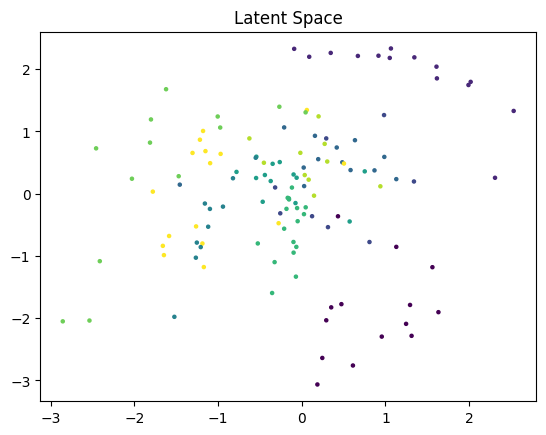

In [18]:
z = torch.cat(z_all)
plt.scatter(z[:,0], z[:,1], c=y_all[0], s=5)
plt.title("Latent Space")
plt.show()

2. GAN (MNIST Image Generation)

Using Generative Adversarial Network

In [19]:
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [20]:
loader = torch.utils.data.DataLoader(
    datasets.MNIST('.', train=True, download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])),
    batch_size=128, shuffle=True)


In [21]:
# Models
G = nn.Sequential(nn.Linear(100, 256), nn.ReLU(), nn.Linear(256, 784), nn.Tanh())
D = nn.Sequential(nn.Linear(784, 256), nn.LeakyReLU(0.2), nn.Linear(256, 1), nn.Sigmoid())

optG = optim.Adam(G.parameters(), 0.0002)
optD = optim.Adam(D.parameters(), 0.0002)
loss_fn = nn.BCELoss()

In [22]:
# Train (short)
for epoch in range(3):
    for real, _ in loader:
        real = real.view(-1, 784)
        z = torch.randn(real.size(0), 100)
        fake = G(z)

        # D
        lossD = loss_fn(D(real), torch.ones_like(D(real))) + \
                loss_fn(D(fake.detach()), torch.zeros_like(D(fake)))
        optD.zero_grad(); lossD.backward(); optD.step()

        # G
        lossG = loss_fn(D(fake), torch.ones_like(D(fake)))
        optG.zero_grad(); lossG.backward(); optG.step()

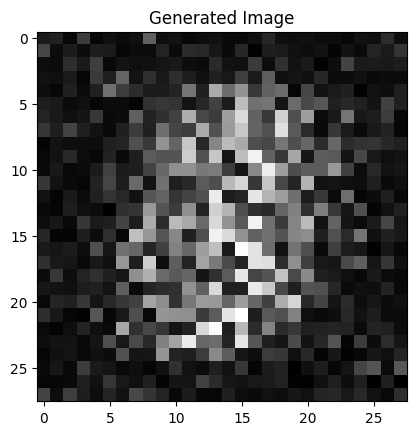

In [23]:
# Generate images
z = torch.randn(1, 100)
img = G(z).view(28,28).detach()
plt.imshow(img, cmap='gray')
plt.title("Generated Image")
plt.show()

3. GCN on Citation Data (Cora)

Using Graph Convolutional Network + PyTorch Geometric

In [24]:
!pip install torch-geometric

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.8 MB/s eta 0:00:00


In [25]:
data = Planetoid(root='/tmp/Cora', name='Cora')[0]

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = GCNConv(data.num_node_features, 16)
        self.c2 = GCNConv(16, data.y.max().item()+1)

    def forward(self):
        x = F.relu(self.c1(data.x, data.edge_index))
        x = self.c2(x, data.edge_index)
        return F.log_softmax(x, dim=1)


Processing...
Done!


In [26]:
model = GCN()
opt = torch.optim.Adam(model.parameters(), lr=0.01)

In [27]:
# Train
for epoch in range(100):
    opt.zero_grad()
    out = model()
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward(); opt.step()

In [28]:
# Accuracy
pred = model().argmax(dim=1)
acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean()
print("Accuracy:", acc.item())

Accuracy: 0.7879999876022339
